# NB to check the WFs from Run 15281

Miryam did a selection in Run 15281 with the WFs that are in the DE peak [1.4, 1.7] MeV. In the table we can find:

* `Zdiffcorr` : $\Delta$ Z
* `S2e` : from DST
* `E_re` : corrected and rescaled energy
* `type` : `good` for events in the upper band, `bad` for events in the lower band, `indi` for events with indistinguisable peaks, `unkwnown` for all the other events (bkg)

In [1]:
import warnings

import tables as tb
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt

In [2]:
selected_events_path = '/mnt/lustre/scratch/nlsas/home/usc/ie/mpm/NEXT100/data/runs/tl208_R15281_selection.h5'

In [3]:
with tb.open_file(selected_events_path, 'r') as h5in:
    print(h5in)

/mnt/lustre/scratch/nlsas/home/usc/ie/mpm/NEXT100/data/runs/tl208_R15281_selection.h5 (File) ''
Last modif.: '2025-06-19T09:09:46+00:00'
Object Tree: 
/ (RootGroup) ''
/DST (Group) ''
/DST/Events (Group) ''
/DST/Events/table (Table(9378,)) ''



In [4]:
sel_events = pd.read_hdf(selected_events_path, 'DST/Events').sort_values(['ldc', 'event'])

In [5]:
sel_events

,event,ldc,file_num,Zdiffcorr,S2e,E_re,type,selection
300987,6716,2,8,95.345274,308955.06250,1.400181,unknown,energy
422468,7297,2,9,137.315831,339575.40625,1.588342,good,energy
417968,12267,2,16,151.321046,306850.90625,1.498004,bad,energy
445011,13569,2,17,133.657746,332502.37500,1.524274,bad,energy
291733,14619,2,19,89.161713,343201.68750,1.604867,indi,energy
...,...,...,...,...,...,...,...,...
1478080,3052944,7,4140,61.561401,307898.65625,1.415622,unknown,energy
1578706,3057473,7,4146,61.592974,298854.31250,1.426552,unknown,energy
1499898,3057760,7,4147,71.615621,348443.09375,1.579219,indi,energy
1698658,3060532,7,4150,75.318577,350641.78125,1.607992,indi,energy


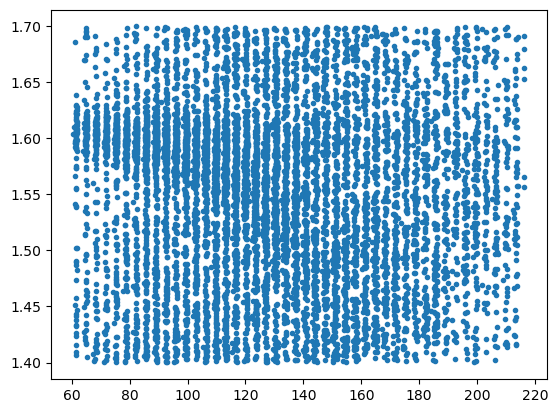

In [6]:
plt.plot(sel_events.Zdiffcorr, sel_events.E_re, '.')


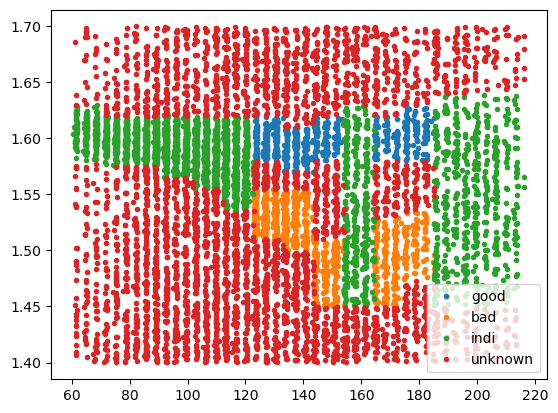

In [7]:
plt.plot(sel_events[sel_events.type == 'good'].Zdiffcorr, sel_events[sel_events.type == 'good'].E_re, '.', label = 'good')
plt.plot(sel_events[sel_events.type == 'bad'].Zdiffcorr, sel_events[sel_events.type == 'bad'].E_re, '.', label = 'bad')
plt.plot(sel_events[sel_events.type == 'indi'].Zdiffcorr, sel_events[sel_events.type == 'indi'].E_re, '.', label = 'indi')
plt.plot(sel_events[sel_events.type == 'unknown'].Zdiffcorr, sel_events[sel_events.type == 'unknown'].E_re, '.', label = 'unknown')
plt.legend()

In [8]:
sel_events.groupby('ldc').count()

,event,file_num,Zdiffcorr,S2e,E_re,type,selection
ldc,,,,,,,
2,1507,1507,1507,1507,1507,1507,1507
3,1562,1562,1562,1562,1562,1562,1562
4,1596,1596,1596,1596,1596,1596,1596
5,1548,1548,1548,1548,1548,1548,1548
6,1562,1562,1562,1562,1562,1562,1562
7,1603,1603,1603,1603,1603,1603,1603


### Miremos una wf

In [9]:
wf_path = '/mnt/lustre/scratch/nlsas/home/usc/ie/mpm/NEXT100/data/runs/15281/selected_wfs/selected_rwf_15281_0000.h5'

In [10]:
with tb.open_file(wf_path, 'r') as h5in:
    print(h5in)

/mnt/lustre/scratch/nlsas/home/usc/ie/mpm/NEXT100/data/runs/15281/selected_wfs/selected_rwf_15281_0000.h5 (File) ''
Last modif.: '2025-06-19T16:01:52+00:00'
Object Tree: 
/ (RootGroup) ''
/evtmap (Table(100,)shuffle, zlib(4)) 'event mapping'
/RD (Group) ''
/RD/pmtrwf (EArray(100, 60, 116000)shuffle, zlib(4)) ''
/RD/sipmrwf (EArray(100, 3584, 2900)shuffle, zlib(4)) ''
/Run (Group) ''
/Run/events (Table(100,)shuffle, zlib(4)) 'event info table'
/Run/runInfo (Table(100,)shuffle, zlib(4)) 'run info table'



In [11]:
pd.read_hdf(wf_path, 'evtmap')

,evt_number,file_no,ldc,filename
0,6716,8,2,run_15281_0008_ldc2_trg2.waveforms
1,7297,9,2,run_15281_0009_ldc2_trg2.waveforms
2,12267,16,2,run_15281_0016_ldc2_trg2.waveforms
3,13569,17,2,run_15281_0017_ldc2_trg2.waveforms
4,14619,19,2,run_15281_0019_ldc2_trg2.waveforms
...,...,...,...,...
95,209555,278,2,run_15281_0278_ldc2_trg2.waveforms
96,209695,278,2,run_15281_0278_ldc2_trg2.waveforms
97,212929,283,2,run_15281_0283_ldc2_trg2.waveforms
98,212992,283,2,run_15281_0283_ldc2_trg2.waveforms


In [12]:
from invisible_cities.cities.components import deconv_pmt
# Parameters for deconvolution
DETECTOR_DB = 'next100'  # As requested, for NEXT100 database
RUN_NUMBER = 15281       # The run number for this analysis
BASELINE_SAMPLES = 4000  # Number of initial samples for baseline/deconvolution


In [13]:
def get_waveform_for_event(filepath, event_number):
    """
    Reads the full PMT RWF for a specific event from a waveform file.
    """
    with tb.open_file(filepath, 'r') as h5file:
        try:
            events_table = h5file.root.Run.events
            pmtrwf_node = h5file.root.RD.pmtrwf
        except tb.NoSuchNodeError as e:
            warnings.warn(f"Required table/group not found in {filepath}: {e}")
            return None

        # Find the index corresponding to the event number
        event_indices = np.where(events_table.col('evt_number') == event_number)[0]
        if len(event_indices) == 0:
            warnings.warn(f"Event {event_number} not found in event map of {filepath}")
            return None
        
        event_index = event_indices[0]
        
        # Read the specific event waveform
        waveform = pmtrwf_node[event_index, :, :]
        return waveform

In [14]:
raw_waveform_data = get_waveform_for_event(wf_path, 6716)
deconvolver = deconv_pmt(DETECTOR_DB, RUN_NUMBER, BASELINE_SAMPLES)
deconvolved_pmts = deconvolver(raw_waveform_data)

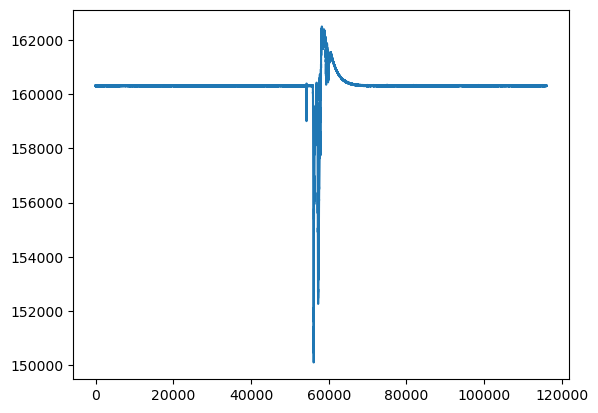

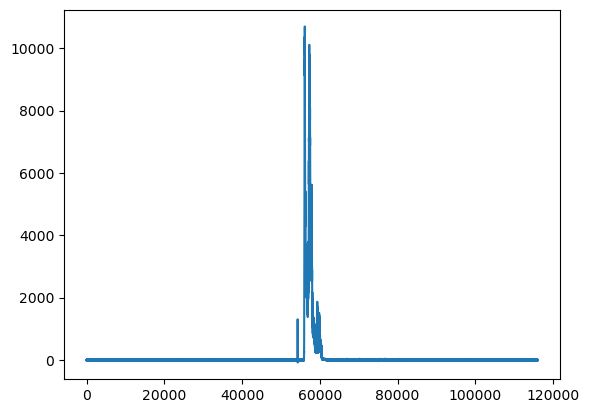

In [15]:
plt.plot(raw_waveform_data.sum(axis = 0))
plt.show()
plt.plot(deconvolved_pmts.sum(axis = 0))

Con esto solo tengo la WF, no los PMAPS, entonces no puedo ver qué es lo que selecciona. Puedo o copiar esos PMAPS, o correr irene y así tb modificar el config como plazca.

## Run Irene

In [16]:
dat_id = 13569 #12267 #6716

In [17]:
import warnings
import tables as tb
import numpy as np

from invisible_cities.core.system_of_units import *
from invisible_cities.types.symbols import SiPMThreshold, WfType

from invisible_cities.cities.components import get_run_number, get_pmt_wfs, get_sipm_wfs, get_trigger_info
from invisible_cities.cities.components import deconv_pmt, calibrate_pmts, zero_suppress_wfs, get_actual_sipm_thr
from invisible_cities.cities.components import check_nonempty_indices, calibrate_sipms, build_pmap, check_empty_pmap


In [18]:
def get_dct_wf(filepath, event_number, wf_type = WfType.rwf):
    """
    Retrieves a dictionary with full event info (PMT/SIPM waveforms, event info, trigger info)
    for a specific event number from a given file, using direct indexing.
    """
    with tb.open_file(filepath, 'r') as h5file:
        try:
            events_table = h5file.root.Run.events
            pmt_wfs      = get_pmt_wfs(h5file, wf_type)
            sipm_wfs     = get_sipm_wfs(h5file, wf_type)
            trg_type, trg_chann = get_trigger_info(h5file)
            run_number   = get_run_number(h5file)
        except tb.NoSuchNodeError as e:
            warnings.warn(f"Missing node in file {filepath}: {e}")
            return None

        # Find the row index corresponding to the event number
        event_indices = np.where(events_table.col('evt_number') == event_number)[0]
        if len(event_indices) == 0:
            warnings.warn(f"Event {event_number} not found in {filepath}")
            return None

        i = event_indices[0]

        # Extract event info
        timestamp = events_table[i]['timestamp']
        pmt       = pmt_wfs[i]
        sipm      = sipm_wfs[i]
        trtyp     = next(trg_type) if trg_type is not None else None
        trchn     = next(trg_chann) if trg_chann is not None else None

        return dict(
            pmt=pmt,
            sipm=sipm,
            run_number=run_number,
            event_number=event_number,
            timestamp=timestamp,
            trigger_type=trtyp,
            trigger_channels=trchn
        )

In [19]:
files_in    = "/jobs/498a72f3-9e59-4d48-8926-d9e793691bb0/run_15281_0000_ldc1_trg2.waveforms.h5"
file_out    = "/jobs/498a72f3-9e59-4d48-8926-d9e793691bb0/run_15281_0000_ldc1_trg2.v2.3.1.20250429.HE.irene.h5"
compression = "ZLIB4"
run_number  = 15281
detector_db = "next100"
print_mod   = 10000
event_range = all


# max number of events to run
event_range = all

n_baseline     =   62400 ### TO BE CHECKED!!!


# Set MAU for calibrated sum
n_maw   = 100
thr_maw =   3 * adc

# Set thresholds for calibrated sum
thr_csum_s1 = 0.1 * pes  ### TO BE CHECKED!!!
thr_csum_s2 = 0.1 * pes  ### TO BE CHECKED!!!

# Set MAU thresholds for SiPM
thr_sipm      = 1.0 * pes
thr_sipm_type = SiPMThreshold.common

# Set parameters to search for S1
s1_tmin       =   0 * mus # 
s1_tmax       =   1380 * mus # 
s1_stride     =   1       # used to be 4 for some reason 
s1_lmin       =   6       # 6 x 25 = 150 ns
s1_lmax       =  40       # 40 x 25 = 1 mus
s1_rebin_stride = 1       # Do not rebin S1 by default

# Set parameters to search for S2
s2_tmin     =      0 * mus  # do not consider full window to speed up 
s2_tmax     =   2800 * mus  # end of the window
s2_stride   =     20        #  40 x 25 = 1   mus
s2_lmin     =    400        # 400 x 25 = 10 mus
s2_lmax     = 1000000        # maximum value of S2 width
s2_rebin_stride = 40        # Rebin by default, 40x25 ns time bins to make one 1us time bin

# Set S2Si parameters
thr_sipm_s2 = 5.0 * pes  # Threshold for the full sipm waveform

pmt_samp_wid  = 25 * ns
sipm_samp_wid =  1 * mus

In [20]:
sipm_thr = get_actual_sipm_thr(thr_sipm_type, thr_sipm, detector_db, run_number)

event = get_dct_wf(wf_path, dat_id)
event['cwf'] = deconv_pmt(detector_db, run_number, n_baseline)(event['pmt'])
event["ccwfs"], event["ccwfs_maw"], event["cwf_sum"], event["cwf_sum_maw"] = calibrate_pmts(detector_db, run_number, n_maw, thr_maw)(event["cwf"])
event["s1_indices"], event["s2_indices"] = zero_suppress_wfs(thr_csum_s1, thr_csum_s2)(event["cwf_sum"], event["cwf_sum_maw"]) #aquí había un output mas pero da error y parece que no se usa

event["indices_pass"] = check_nonempty_indices(event["s1_indices"], event["s2_indices"])
event['sipm'] = calibrate_sipms(detector_db, run_number, sipm_thr)(event['sipm']) #entiendo que lo que hace esta funcion es sobreescribir sobre el mismo item 'sipm', en lugar de tener input/output

event["pmap"] = build_pmap(detector_db, run_number, pmt_samp_wid, sipm_samp_wid,
                                         s1_lmax, s1_lmin, s1_rebin_stride, s1_stride, s1_tmax, s1_tmin,
                                         s2_lmax, s2_lmin, s2_rebin_stride, s2_stride, s2_tmax, s2_tmin, thr_sipm_s2)(event["ccwfs"], event["s1_indices"], event["s2_indices"], event['sipm'])

event['pmaps_pass'] = check_empty_pmap(event["pmap"])

Ahora me falta de PMAP object a DF para poder plotear

In [21]:
def store_peak_df(peak, peak_number, event, pmt_list, pmti_list, si_list):
    for i, t in enumerate(peak.times):
        pmt_list.append({
            'event' : event,
            'peak'  : peak_number,
            'time'  : t,
            'bwidth': peak.bin_widths[i],
            'ene'   : peak.pmts.sum_over_sensors[i]
        })

    for pmt_id in peak.pmts.ids:
        for e in peak.pmts.waveform(pmt_id):
            pmti_list.append({
                'event': event,
                'peak' : peak_number,
                'npmt' : pmt_id,
                'ene'  : e
            })

    if peak.sipms is not None and si_list is not None:
        for sipm_id in peak.sipms.ids:
            for q in peak.sipms.waveform(sipm_id):
                si_list.append({
                    'event': event,
                    'peak' : peak_number,
                    'nsipm': sipm_id,
                    'ene'  : q
                })

def pmap_to_dfs(pmap, event_number):
    s1_rows    = []
    s2_rows    = []
    s2si_rows  = []
    s1pmt_rows = []
    s2pmt_rows = []

    for peak_number, s1 in enumerate(pmap.s1s):
        store_peak_df(s1, peak_number, event_number, s1_rows, s1pmt_rows, None)

    for peak_number, s2 in enumerate(pmap.s2s):
        store_peak_df(s2, peak_number, event_number, s2_rows, s2pmt_rows, s2si_rows)

    return {
        'S1'   : pd.DataFrame(s1_rows),
        'S2'   : pd.DataFrame(s2_rows),
        'S2Si' : pd.DataFrame(s2si_rows),
        'S1Pmt': pd.DataFrame(s1pmt_rows),
        'S2Pmt': pd.DataFrame(s2pmt_rows)
    }


In [22]:
event['pmap_df'] = pmap_to_dfs(event['pmap'], dat_id)

In [23]:
s1, s2, s2sipm, s1pmt, s2pmt = event['pmap_df']['S1'], event['pmap_df']['S2'], event['pmap_df']['S2Si'], event['pmap_df']['S1Pmt'], event['pmap_df']['S2Pmt']

In [24]:
deconvolved_wf_sum = np.sum(event['cwf'], axis=0)
time_axis_us = np.arange(len(deconvolved_wf_sum)) * pmt_samp_wid  / 1000

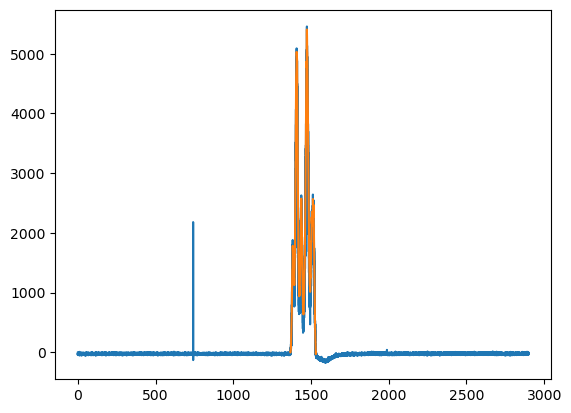

In [25]:
plt.plot(time_axis_us, deconvolved_wf_sum, label = 'WF')
plt.plot(s2.time / 1000, s2.ene, label = 'S2 peak')
# plt.title('PMT CWF')
# plt.xlim((1300, 1700))

In [141]:
sel_events

,event,ldc,file_num,Zdiffcorr,S2e,E_re,type,selection
300987,6716,2,8,95.345274,308955.06250,1.400181,unknown,energy
422468,7297,2,9,137.315831,339575.40625,1.588342,good,energy
417968,12267,2,16,151.321046,306850.90625,1.498004,bad,energy
445011,13569,2,17,133.657746,332502.37500,1.524274,bad,energy
291733,14619,2,19,89.161713,343201.68750,1.604867,indi,energy
...,...,...,...,...,...,...,...,...
1478080,3052944,7,4140,61.561401,307898.65625,1.415622,unknown,energy
1578706,3057473,7,4146,61.592974,298854.31250,1.426552,unknown,energy
1499898,3057760,7,4147,71.615621,348443.09375,1.579219,indi,energy
1698658,3060532,7,4150,75.318577,350641.78125,1.607992,indi,energy
